In [9]:
import pandas as pd
from sklearn.datasets import load_iris
iris_raw=load_iris()
iris_pd=pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
iris_pd.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
iris_pd.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [11]:
iris_pd['species_id']=iris_raw.target
species_mapping={i: names for i , names in enumerate(iris_raw.feature_names)}
iris_pd['species_name']=iris_pd['species_id'].map(species_mapping)

In [12]:
for i in iris_raw.feature_names:
  mean_val=iris_pd[i].mean()
  median_val=iris_pd[i].median()
  mode_val=iris_pd[i].mode()[0]
  print( f"Feature :{i}")
  print(f"MEAN:{mean_val:.4f}cm")
  print(f"MEDIAN:{median_val:.4f} cm")
  print(f"Mode :{mode_val:.4f} cm")
  print(f"-" *40)

Feature :sepal length (cm)
MEAN:5.8433cm
MEDIAN:5.8000 cm
Mode :5.0000 cm
----------------------------------------
Feature :sepal width (cm)
MEAN:3.0573cm
MEDIAN:3.0000 cm
Mode :3.0000 cm
----------------------------------------
Feature :petal length (cm)
MEAN:3.7580cm
MEDIAN:4.3500 cm
Mode :1.4000 cm
----------------------------------------
Feature :petal width (cm)
MEAN:1.1993cm
MEDIAN:1.3000 cm
Mode :0.2000 cm
----------------------------------------


In [13]:
for i in iris_raw.feature_names :
  std_val=iris_pd[i].std()
  var_val=iris_pd[i].var()
  range_val=iris_pd[i].max() - iris_pd[i].min()
  q1=iris_pd[i].quantile(0.75)
  q2=iris_pd[i].quantile(0.67)
  print(f"ST:{std_val:.4f} cm")
  print(f"VAR:{var_val:.4f}cm")
  print(f"RANGE:{range_val}")
  print(f"QUANTILE :{q1-q2:.4f} cm")
  print(f"_" *40 )

ST:0.8281 cm
VAR:0.6857cm
RANGE:3.6000000000000005
QUANTILE :0.1000 cm
________________________________________
ST:0.4359 cm
VAR:0.1900cm
RANGE:2.4000000000000004
QUANTILE :0.1000 cm
________________________________________
ST:1.7653 cm
VAR:3.1163cm
RANGE:5.9
QUANTILE :0.2000 cm
________________________________________
ST:0.7622 cm
VAR:0.5810cm
RANGE:2.4
QUANTILE :0.2000 cm
________________________________________


In [14]:
for i in iris_raw.feature_names:
  skw_val=iris_pd[i].skew()
  kut_val=iris_pd[i].kurtosis()
  print(f"  Skewness (Asymmetry): {skw_val:.4f}")
  print(f" kurtosis:{kut_val:.4f}")
  print(f"-"*40)


  Skewness (Asymmetry): 0.3149
 kurtosis:-0.5521
----------------------------------------
  Skewness (Asymmetry): 0.3190
 kurtosis:0.2282
----------------------------------------
  Skewness (Asymmetry): -0.2749
 kurtosis:-1.4021
----------------------------------------
  Skewness (Asymmetry): -0.1030
 kurtosis:-1.3406
----------------------------------------


In [15]:
grouped_by=iris_pd.groupby('species_name')
print(grouped_by[iris_raw.feature_names].mean())


                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
species_name                                                                
petal length (cm)              6.588             2.974              5.552   
sepal length (cm)              5.006             3.428              1.462   
sepal width (cm)               5.936             2.770              4.260   

                   petal width (cm)  
species_name                         
petal length (cm)             2.026  
sepal length (cm)             0.246  
sepal width (cm)              1.326  


In [16]:
aggregated_stats = iris_pd.groupby('species_name')['petal length (cm)'].agg(['mean', 'median', 'std', 'skew'])
print("Aggregated Statistics (Petal Length):\n", aggregated_stats)

Aggregated Statistics (Petal Length):
                     mean  median       std      skew
species_name                                        
petal length (cm)  5.552    5.55  0.551895  0.549445
sepal length (cm)  1.462    1.50  0.173664  0.106394
sepal width (cm)   4.260    4.35  0.469911 -0.606508


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
df = sns.load_dataset("titanic")
print("First 5 Rows")
print(df.head())
print("\nLast 5 Rows")
print(df.tail())
print("\nRandom 5 Rows")
print(df.sample(5))

First 5 Rows
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Last 5 Rows
     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0    

In [19]:
print("Shape :", df.shape)

Shape : (891, 15)


In [20]:
print("\nNumber of Rows :", df.shape[0])


Number of Rows : 891


In [21]:
print("\nNumber of Columns :", df.shape[1])


Number of Columns : 15


In [22]:
print("\nColumn Names")
print(df.columns)


Column Names
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [23]:
print("\nData Types")
print(df.dtypes)


Data Types
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [24]:
print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [25]:
print("Statistical Summary")
print(df.describe())

Statistical Summary
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [26]:
print("\nSummary Including Categorical Columns")
print(df.describe(include='all'))


Summary Including Categorical Columns
          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    2.000000   NaN   20.125000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.000000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   38.000000    1.000000    0.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              fare embarked  class  who adult_ma

In [27]:

print("Missing Values")
print(df.isnull().sum())

Missing Values
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [28]:
print("\nDuplicate Rows")
print(df.duplicated().sum())


Duplicate Rows
107


In [29]:
print("\nUnique Values")
print(df.nunique())


Unique Values
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


Text(0.5, 1.0, 'Survival Count 24EU01112')

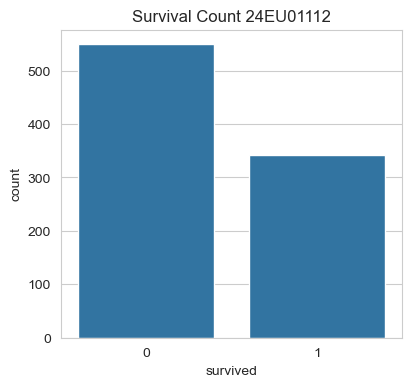

In [30]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.countplot(x='survived', data=df)
plt.title("Survival Count 24EU01112")